In [1]:
import seaborn as sns
import numpy as np
import pandas as pd

In [6]:
df = sns.load_dataset("penguins").bfill()
df.head(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [7]:
df.shape

(344, 7)

In [8]:
df.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [11]:
df['island'].unique()

<ArrowStringArray>
['Torgersen', 'Biscoe', 'Dream']
Length: 3, dtype: str

In [12]:
df['species'].unique()

<ArrowStringArray>
['Adelie', 'Chinstrap', 'Gentoo']
Length: 3, dtype: str

In [13]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded_cols = ohe.fit_transform(df[['sex', 'island','species']])

In [14]:
encoded_df = pd.DataFrame(
    encoded_cols,
    columns=ohe.get_feature_names_out(['sex', 'island','species'])
)

# 2. Purane text columns ko hatakar naye encoded columns merge karein
df = df.drop(columns=['sex', 'island','species']).reset_index(drop=True)
df = pd.concat([df, encoded_df], axis=1)

df.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex_Male,island_Dream,island_Torgersen,species_Chinstrap,species_Gentoo
0,39.1,18.7,181.0,3750.0,1.0,0.0,1.0,0.0,0.0
1,39.5,17.4,186.0,3800.0,0.0,0.0,1.0,0.0,0.0
2,40.3,18.0,195.0,3250.0,0.0,0.0,1.0,0.0,0.0
3,36.7,19.3,193.0,3450.0,0.0,0.0,1.0,0.0,0.0
4,36.7,19.3,193.0,3450.0,0.0,0.0,1.0,0.0,0.0


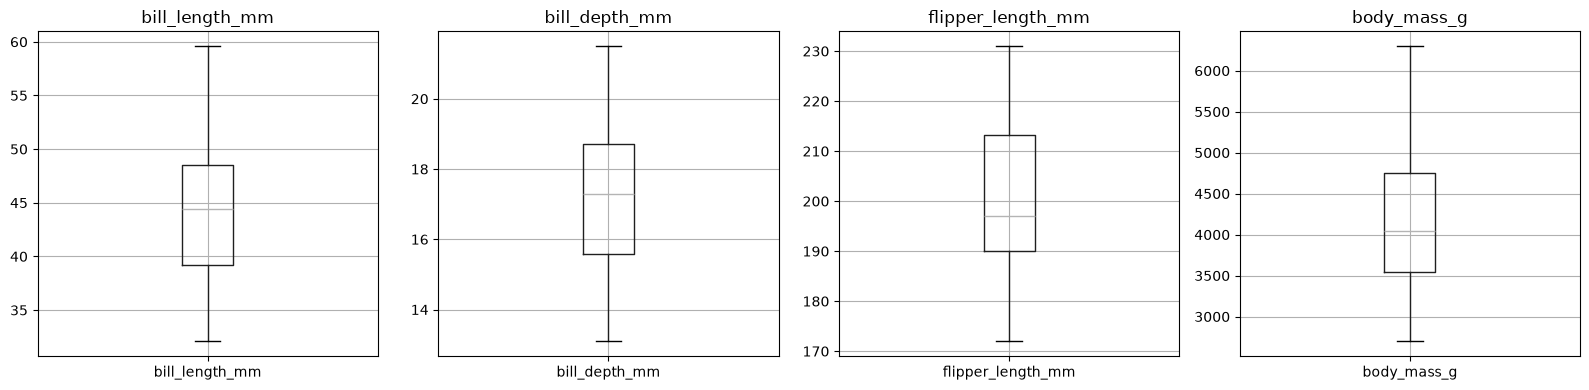

In [15]:
import matplotlib.pyplot as plt

numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, numeric_cols):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [16]:
from sklearn.preprocessing import MinMaxScaler

min_max = MinMaxScaler()

num_cols = ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']
df[num_cols] = min_max.fit_transform(df[num_cols])

df.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex_Male,island_Dream,island_Torgersen,species_Chinstrap,species_Gentoo
0,0.254545,0.666667,0.152542,0.291667,1.0,0.0,1.0,0.0,0.0
1,0.269091,0.511905,0.237288,0.305556,0.0,0.0,1.0,0.0,0.0
2,0.298182,0.583333,0.389831,0.152778,0.0,0.0,1.0,0.0,0.0
3,0.167273,0.738095,0.355932,0.208333,0.0,0.0,1.0,0.0,0.0
4,0.167273,0.738095,0.355932,0.208333,0.0,0.0,1.0,0.0,0.0


In [21]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['species_Chinstrap','species_Gentoo'])
y = df[['species_Chinstrap','species_Gentoo']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred)*100)

Accuracy: 98.55072463768117


In [28]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt) * 100)

Decision Tree Accuracy: 95.65217391304348
